<a href="https://colab.research.google.com/github/Manavee-Singh-811/Quant-Journey-2026/blob/main/Day_02_Statistical_Anomalies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt


In [7]:
df = yf.download("^NSEI", period ="1y") #NIFTY 50

/tmp/ipykernel_381/1300569021.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^NSEI", period ="1y") #NIFTY 50
[*********************100%***********************]  1 of 1 completed


In [8]:
df['Returns'] = df['Close'].pct_change()

In [10]:
df['Z_Score'] = (df['Returns']- df['Returns'].mean())/ df['Returns'].std()

In [12]:
signals = df[np.abs(df['Z_Score'])> 3] #Identify 'Extreme' Days (> 3 Sigma events)

In [13]:
print("Extreme Market Events found:")
print(signals[['Close', 'Z_Score']])

Extreme Market Events found:
Price              Close   Z_Score
Ticker             ^NSEI          
Date                              
2025-04-07  22161.599609 -4.311559
2025-05-12  24924.699219  4.977967
2026-02-03  25727.550781  3.306335


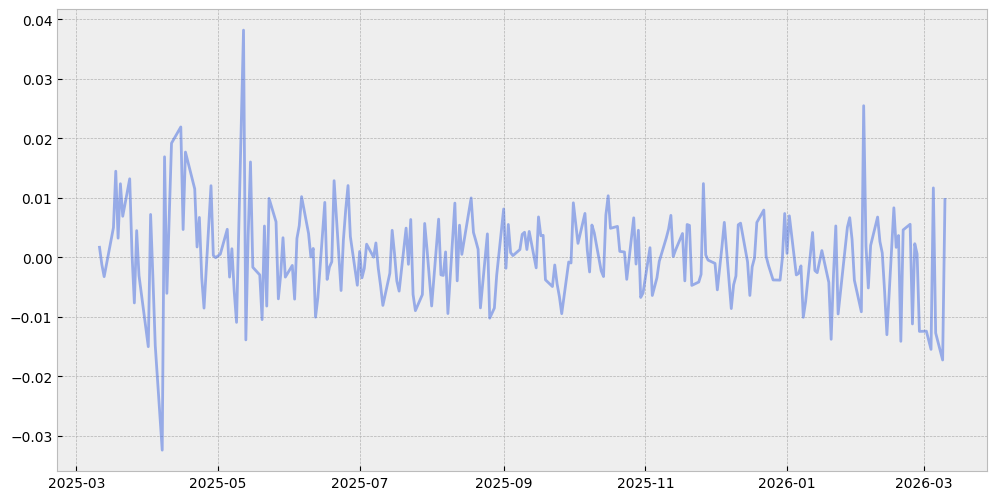

In [19]:
plt.style.use('bmh')
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Returns'], label='Daily Returns', alpha=0.5, color='royalblue') #Plot the Daily Returns

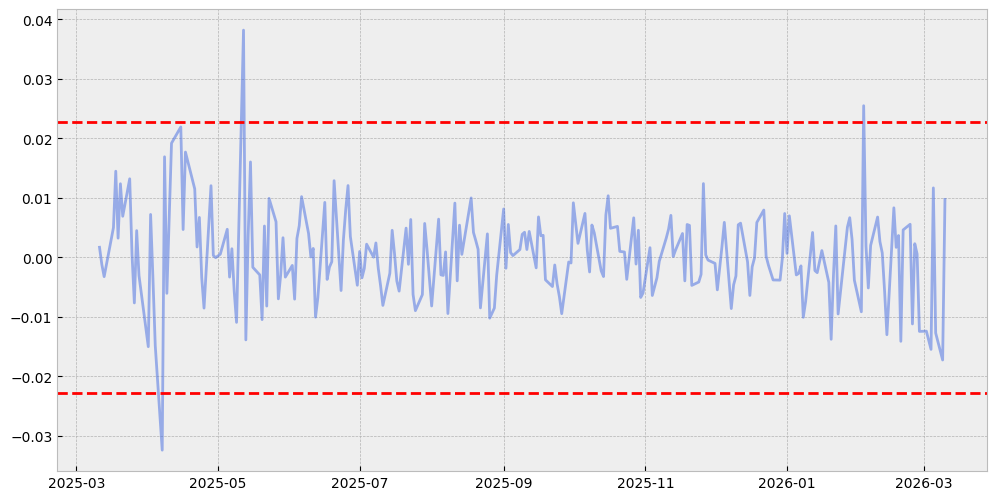

In [26]:
plt.style.use('bmh')
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Returns'], label='Daily Returns', alpha=0.5, color='royalblue') #Plot the Daily Returns

# 2. Add 'Sigma' Threshold Lines (The "Danger Zones")
plt.axhline(y=3*df['Returns'].std(), color='red', linestyle='--', label='3-Sigma Upper')
plt.axhline(y=-3*df['Returns'].std(), color='red', linestyle='--', label='3-Sigma Lower')

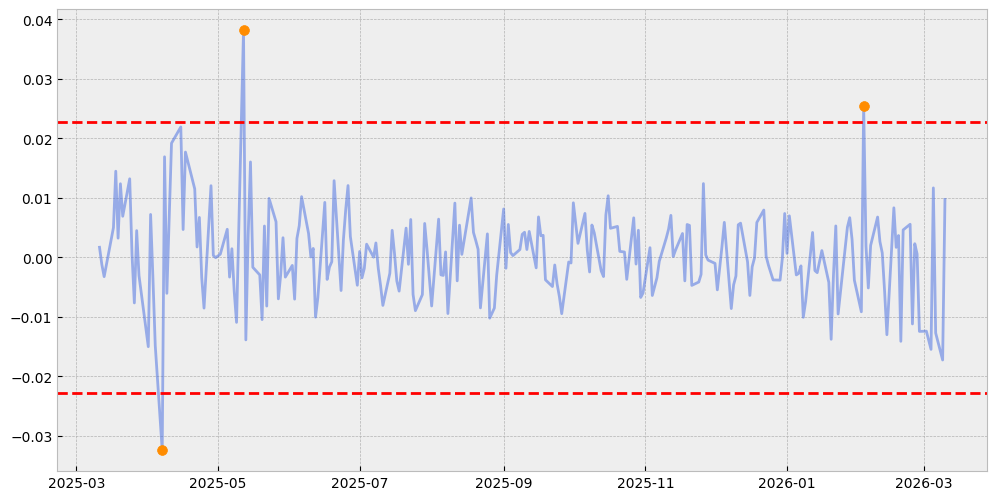

In [27]:
plt.style.use('bmh')
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Returns'], label='Daily Returns', alpha=0.5, color='royalblue') #Plot the Daily Returns

# 2. Add 'Sigma' Threshold Lines (The "Danger Zones")
plt.axhline(y=3*df['Returns'].std(), color='red', linestyle='--', label='3-Sigma Upper')
plt.axhline(y=-3*df['Returns'].std(), color='red', linestyle='--', label='3-Sigma Lower')

# 3. Highlight the specific 'Extreme' signal points
ax.scatter(signals.index, signals['Returns'], color='darkorange', s=50, label='Anomalous Signal', zorder=5)

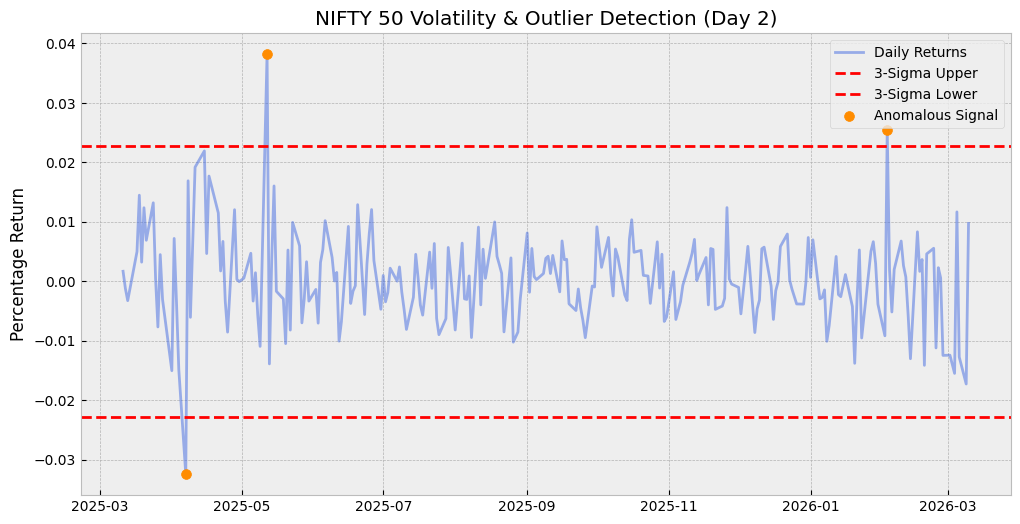

In [28]:
plt.style.use('bmh')
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Returns'], label='Daily Returns', alpha=0.5, color='royalblue') #Plot the Daily Returns

# 2. Add 'Sigma' Threshold Lines (The "Danger Zones")
plt.axhline(y=3*df['Returns'].std(), color='red', linestyle='--', label='3-Sigma Upper')
plt.axhline(y=-3*df['Returns'].std(), color='red', linestyle='--', label='3-Sigma Lower')

# 3. Highlight the specific 'Extreme' signal points
ax.scatter(signals.index, signals['Returns'], color='darkorange', s=50, label='Anomalous Signal', zorder=5)

ax.set_title(f"NIFTY 50 Volatility & Outlier Detection (Day 2)")
ax.set_ylabel("Percentage Return")
ax.legend()
plt.show()

# Observation:

The NIFTY 50 exhibits 'Fat Tails.' While a Normal Distribution suggests 3-sigma events should happen once every ~370 days, observed market data often shows them occurring more frequently, indicating non-normal risk (Kurtosis).